In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
# Importing the dataset
Development = pd.read_csv("../Dataset/HDI.csv")

# Listing the first five rows of the dataset
Development.head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [3]:
# Check shape and column names
print("Shape:", Development.shape)
print("\nColumn Names:")
for i, col in enumerate(Development.columns):
    print(i, col)

Shape: (195, 880)

Column Names:
0 ISO3
1 Country
2 Human Development Groups
3 UNDP Developing Regions
4 HDI Rank (2021)
5 Human Development Index (1990)
6 Human Development Index (1991)
7 Human Development Index (1992)
8 Human Development Index (1993)
9 Human Development Index (1994)
10 Human Development Index (1995)
11 Human Development Index (1996)
12 Human Development Index (1997)
13 Human Development Index (1998)
14 Human Development Index (1999)
15 Human Development Index (2000)
16 Human Development Index (2001)
17 Human Development Index (2002)
18 Human Development Index (2003)
19 Human Development Index (2004)
20 Human Development Index (2005)
21 Human Development Index (2006)
22 Human Development Index (2007)
23 Human Development Index (2008)
24 Human Development Index (2009)
25 Human Development Index (2010)
26 Human Development Index (2011)
27 Human Development Index (2012)
28 Human Development Index (2013)
29 Human Development Index (2014)
30 Human Development Index (2015)


In [4]:
# Select and rename the relevant columns for our project
Development = Development[[
    'Country',
    'Human Development Groups',
    'HDI Rank (2021)',
    'Human Development Index (2021)',
    'Life Expectancy at Birth (2021)',
    'Mean Years of Schooling (2021)',
    'Gross National Income Per Capita (2021)'
]]

# Rename columns to shorter names
Development.columns = [
    'Country',
    'HDI Group',
    'HDI Rank',
    'HDI',
    'Life expectancy',
    'Mean years of schooling',
    'Gross national income (GNI) per capita'
]

print("Shape:", Development.shape)
Development.head()

Shape: (195, 7)


,Country,HDI Group,HDI Rank,HDI,Life expectancy,Mean years of schooling,Gross national income (GNI) per capita
0,Afghanistan,Low,180.0,0.478,61.9824,2.985070,1824.190915
1,Angola,Medium,148.0,0.586,61.6434,5.417391,5465.617791
2,Albania,High,67.0,0.796,76.4626,11.286455,14131.110390
3,Andorra,Very High,40.0,0.858,80.3684,10.555120,51166.626610
4,United Arab Emirates,Very High,26.0,0.911,78.7104,12.694030,62573.591810


In [5]:
# Check shape
print("Shape:", Development.shape)

# Check null values
print("\nNull values:")
print(Development.isnull().sum())

Shape: (195, 7)

Null values:
Country                                   0
HDI Group                                 4
HDI Rank                                  4
HDI                                       4
Life expectancy                           0
Mean years of schooling                   4
Gross national income (GNI) per capita    2
dtype: int64


In [6]:
# Fill null values with mean for numerical columns
Development['HDI'].fillna(Development['HDI'].mean(), inplace=True)
Development['HDI Rank'].fillna(Development['HDI Rank'].mean(), inplace=True)
Development['Mean years of schooling'].fillna(Development['Mean years of schooling'].mean(), inplace=True)
Development['Gross national income (GNI) per capita'].fillna(Development['Gross national income (GNI) per capita'].mean(), inplace=True)

# Fill HDI Group with most common value
Development['HDI Group'].fillna(Development['HDI Group'].mode()[0], inplace=True)

# Verify no nulls remain
print("Null values after filling:")
print(Development.isnull().sum())

Null values after filling:
Country                                   0
HDI Group                                 0
HDI Rank                                  0
HDI                                       0
Life expectancy                           0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64


In [7]:
# Use first 20 rows for visualization
data1 = Development.head(20)

# Check unique country values
print(Development['Country'].unique())

['Afghanistan' 'Angola' 'Albania' 'Andorra' 'United Arab Emirates'
 'Argentina' 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria'
 'Azerbaijan' 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh'
 'Bulgaria' 'Bahrain' 'Bahamas' 'Bosnia and Herzegovina' 'Belarus'
 'Belize' 'Bolivia' 'Brazil' 'Barbados' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 'Ivory Coast' 'Cameroon' 'The Democratic Republic of the Congo' 'Congo'
 'Colombia' 'Comoros' 'Cabo Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia'
 'Germany' 'Djibouti' 'Dominica' 'Denmark' 'Dominican Republic' 'Algeria'
 'Ecuador' 'Egypt' 'Eritrea' 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji'
 'France' 'Micronesia' 'Gabon' 'United Kingdom' 'Georgia' 'Ghana' 'Guinea'
 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece' 'Grenada'
 'Guatemala' 'Guyana' 'Hong Kong' 'Honduras' 'Croatia' 'Haiti' 'Hungary'
 'Indonesia' 'India' 'Ireland' 'Iran' 'Iraq' 'Iceland' 'Israel' 'Italy'
 'Jamaica' '

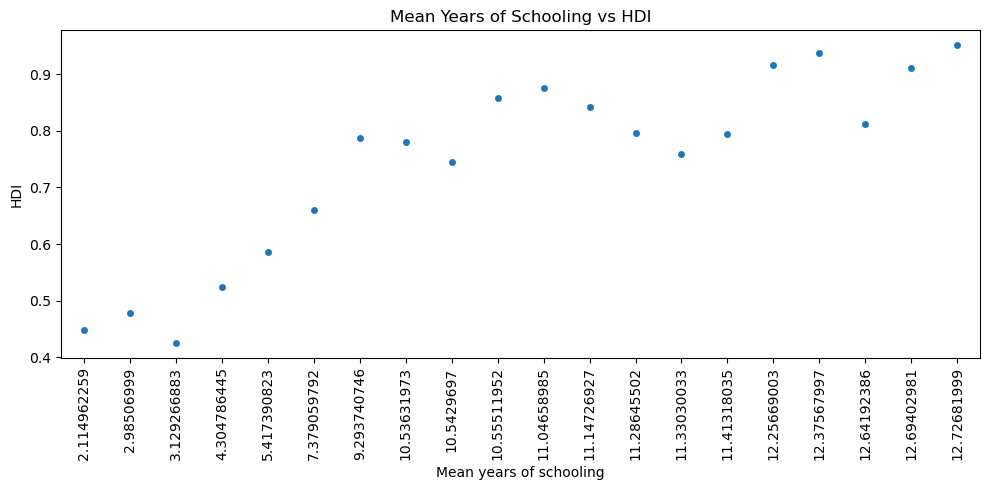

In [8]:
# Strip Plot: Mean Years of Schooling vs HDI
plt.figure(figsize=(10, 5))
g = sns.stripplot(x='Mean years of schooling', y='HDI', data=data1, jitter=True)
plt.xticks(rotation=90)
plt.title('Mean Years of Schooling vs HDI')
plt.tight_layout()
plt.show()

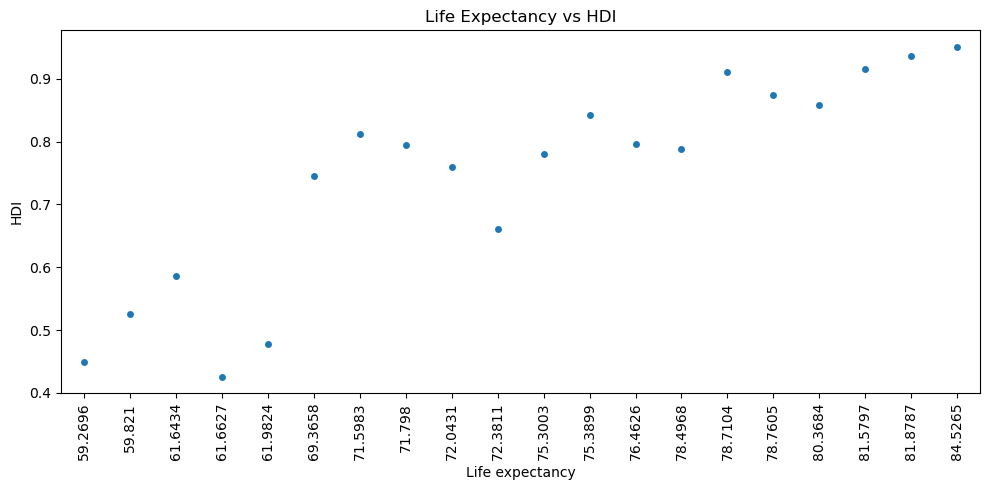

In [9]:
# Strip Plot: Life Expectancy vs HDI
plt.figure(figsize=(10, 5))
g = sns.stripplot(x='Life expectancy', y='HDI', data=data1, jitter=True)
plt.xticks(rotation=90)
plt.title('Life Expectancy vs HDI')
plt.tight_layout()
plt.show()

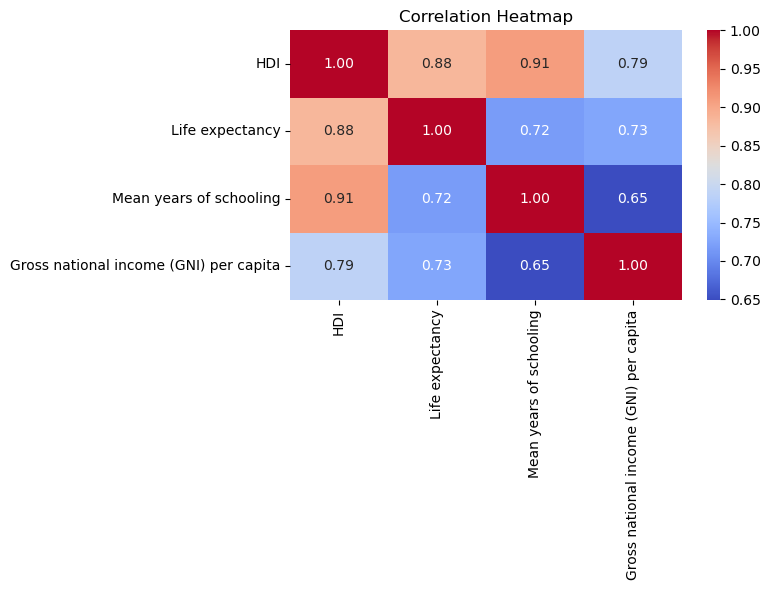

In [10]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
heat = Development[['HDI', 'Life expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita']]
sns.heatmap(heat.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

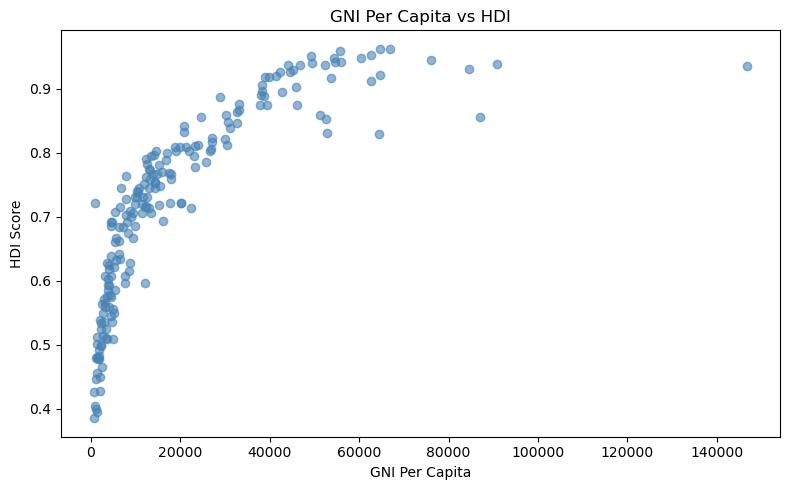

In [11]:
# GNI per Capita vs HDI
plt.figure(figsize=(8, 5))
plt.scatter(Development['Gross national income (GNI) per capita'], Development['HDI'], color='steelblue', alpha=0.6)
plt.xlabel('GNI Per Capita')
plt.ylabel('HDI Score')
plt.title('GNI Per Capita vs HDI')
plt.tight_layout()
plt.show()

In [12]:
# Independent Variables (X)
X = Development[['Country', 'Life expectancy', 'Mean years of schooling', 'Gross national income (GNI) per capita']]
X = pd.DataFrame(X)

# Dependent Variable (y) - HDI score
y = Development['HDI'].values
y = pd.DataFrame(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 rows of X:")
X.head()

X shape: (195, 4)
y shape: (195, 1)

First 5 rows of X:


,Country,Life expectancy,Mean years of schooling,Gross national income (GNI) per capita
0,Afghanistan,61.9824,2.985070,1824.190915
1,Angola,61.6434,5.417391,5465.617791
2,Albania,76.4626,11.286455,14131.110390
3,Andorra,80.3684,10.555120,51166.626610
4,United Arab Emirates,78.7104,12.694030,62573.591810


In [13]:
# Label Encoding for Country column
le = LabelEncoder()
X['Country'] = le.fit_transform(X['Country'].astype(str))

print("Label Encoding applied!")
print("\nFirst 5 rows after encoding:")
X.head()

Label Encoding applied!

First 5 rows after encoding:


,Country,Life expectancy,Mean years of schooling,Gross national income (GNI) per capita
0,0,61.9824,2.985070,1824.190915
1,4,61.6434,5.417391,5465.617791
2,1,76.4626,11.286455,14131.110390
3,3,80.3684,10.555120,51166.626610
4,184,78.7104,12.694030,62573.591810


In [14]:
# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Training set size: (175, 4)
Testing set size: (20, 4)


In [15]:
# Initialize and train the Linear Regression model
reg = LinearRegression()
reg.fit(x_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
# Save the trained model
pickle.dump(reg, open('../Flask/HDI.pkl', 'wb'))

print("Model saved successfully as HDI.pkl!")

Model saved successfully as HDI.pkl!


In [17]:
import os
print(os.getcwd())

C:\Users\yeshi\Desktop\HDI Project\Training


In [18]:
pickle.dump(reg, open('C:/Users/yeshi/Desktop/HDI Project/Flask/HDI.pkl', 'wb'))
print("Model saved successfully!")

Model saved successfully!


In [19]:
import os

path = 'C:/Users/yeshi/Desktop/HDI Project/Flask/'
print("Files in Flask folder:")
print(os.listdir(path))

Files in Flask folder:
['HDI.pkl']


In [20]:
import shutil
shutil.copy(
    'C:/Users/yeshi/Desktop/HDI Project/Flask/HDI.pkl',
    'C:/Users/yeshi/OneDrive/Desktop/HDI Project/Flask/HDI.pkl'
)
print("Copied successfully!")

Copied successfully!


In [25]:
import os
print(os.listdir('C:/Users/yeshi/OneDrive/Desktop/HDI Project/Flask/templates'))

['home.html', 'indexnew.html', 'resultnew.html']
